# Extended Analysis: Predictive Maintenance Dataset

This notebook extends the analysis from `stat-lab-test.ipynb` with:
1. **Deeper EDA** — statistical summaries, outlier analysis, feature engineering insights
2. **Feature Importance Plots** — from Random Forest, Logistic Regression coefficients, permutation importance
3. **Model Interpretability** — confusion matrices, ROC curves, precision-recall curves, SHAP values
4. **Model Comparison** — consolidated accuracy/F1 tables and visualizations across all models and targets

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

try:
    df = pd.read_csv(r'C:\Users\johnf\forks\Statistical-Learning-Lab-Test\ai4i2020.csv')
except FileNotFoundError:
    df = pd.read_csv('ai4i2020.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df = df.drop(columns=['UDI', 'Product ID'])
all_tar = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
feature_cols = [c for c in df.columns if c not in all_tar]
print('Feature columns:', feature_cols)
print('Target columns:', all_tar)

Feature columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Target columns: ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [ ]:
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
df['Wear_Load'] = df['Tool wear [min]'] * df['Torque [Nm]']
df['Temp_ratio'] = df['Process temperature [K]'] / df['Air temperature [K]']

---
## 2. Extended Exploratory Data Analysis (EDA)

### 2.1 Statistical Summary

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,NaN,NaN,NaN,0.0115,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,NaN,NaN,NaN,0.0095,0.097009,0.0,0.0,0.0,0.0,1.0


In [5]:
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})
info_df

,dtype,non_null,null_count,null_pct,n_unique
Type,str,10000,0,0.0,3
Air temperature [K],float64,10000,0,0.0,93
Process temperature [K],float64,10000,0,0.0,82
Rotational speed [rpm],int64,10000,0,0.0,941
Torque [Nm],float64,10000,0,0.0,577
Tool wear [min],int64,10000,0,0.0,246
Machine failure,int64,10000,0,0.0,2
TWF,int64,10000,0,0.0,2
HDF,int64,10000,0,0.0,2
PWF,int64,10000,0,0.0,2


### 2.2 Target Variable Analysis

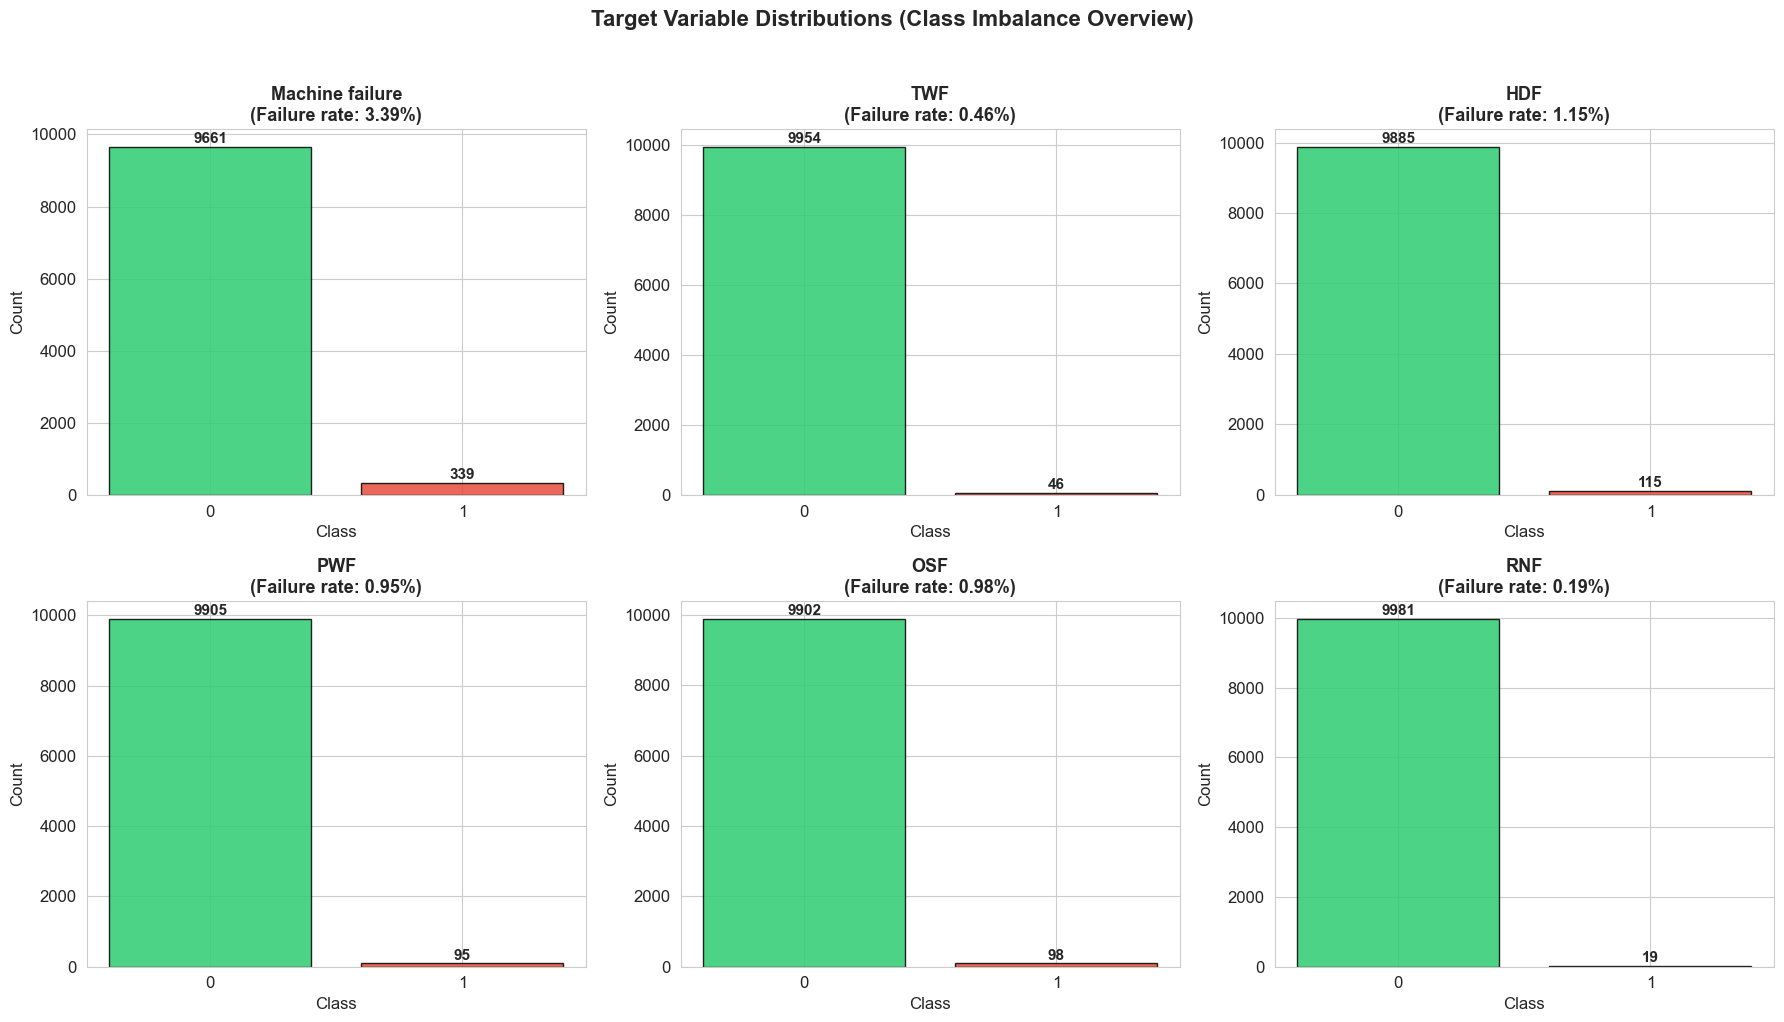

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(all_tar):
    counts = df[col].value_counts()
    pcts = (counts / len(df) * 100).round(2)
    bars = axes[i].bar(counts.index.astype(str), counts.values, 
                       color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col}\n(Failure rate: {pcts.get(1, 0):.2f}%)', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Target Variable Distributions (Class Imbalance Overview)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

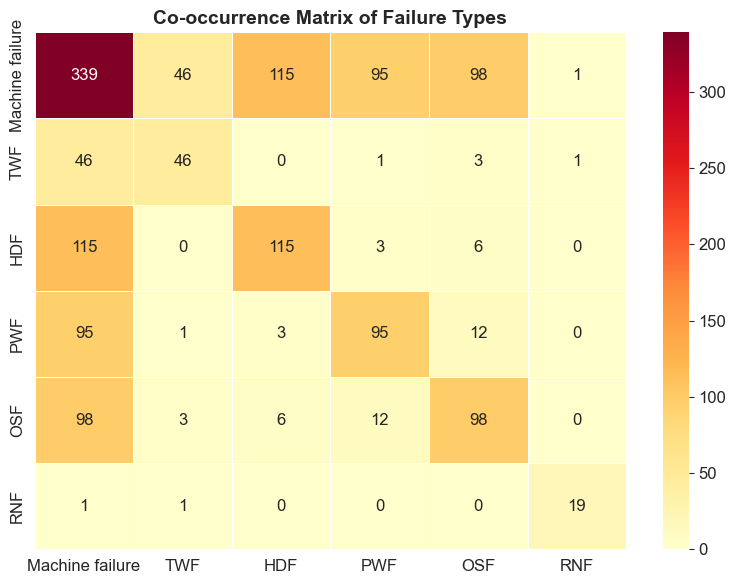

In [7]:
failure_cooccurrence = df[all_tar].T.dot(df[all_tar])

plt.figure(figsize=(8, 6))
sns.heatmap(failure_cooccurrence, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Failure Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Enhanced Correlation Analysis

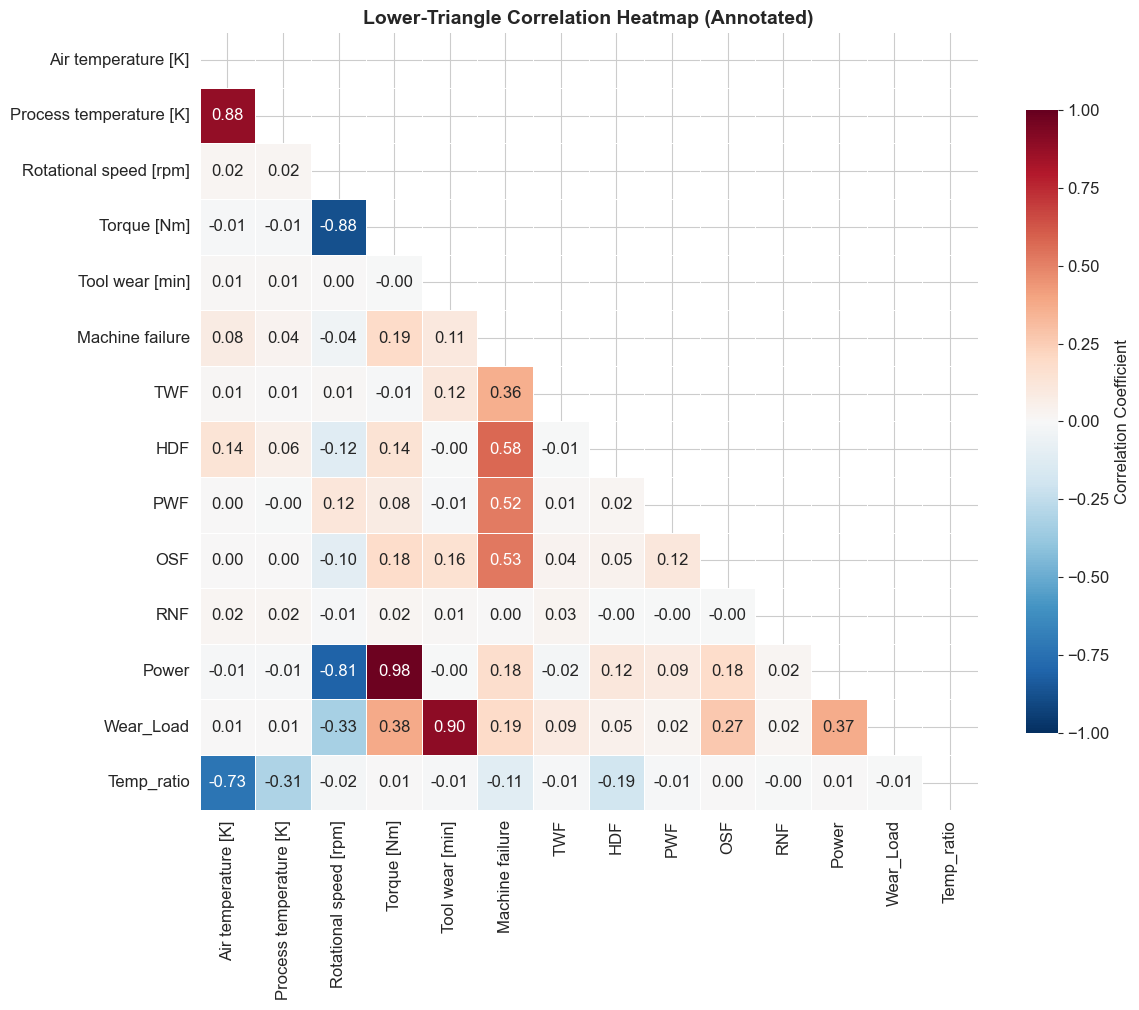

In [8]:
numeric_df = df.drop(columns=['Type'])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})
plt.title('Lower-Triangle Correlation Heatmap (Annotated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

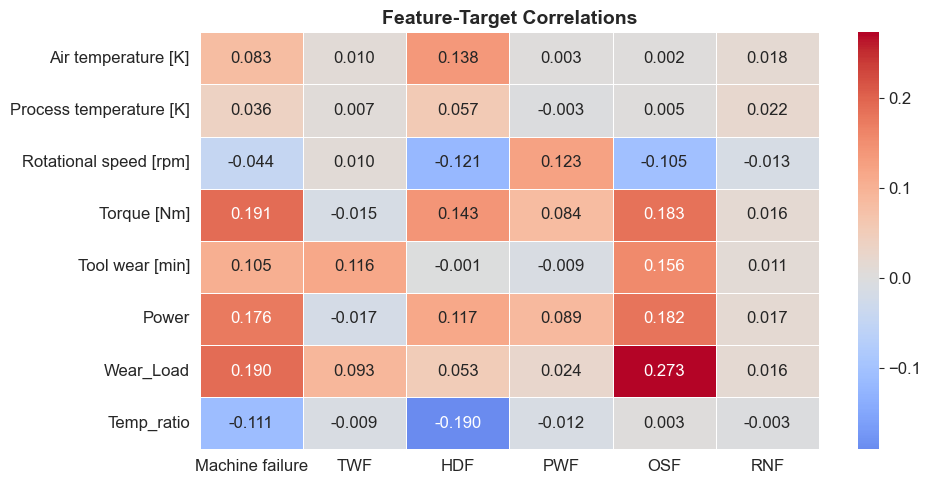

In [9]:
target_corr = corr[all_tar].drop(index=all_tar)

plt.figure(figsize=(10, 5))
sns.heatmap(target_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature-Target Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Feature Distribution Analysis (Box plots & Violin plots)

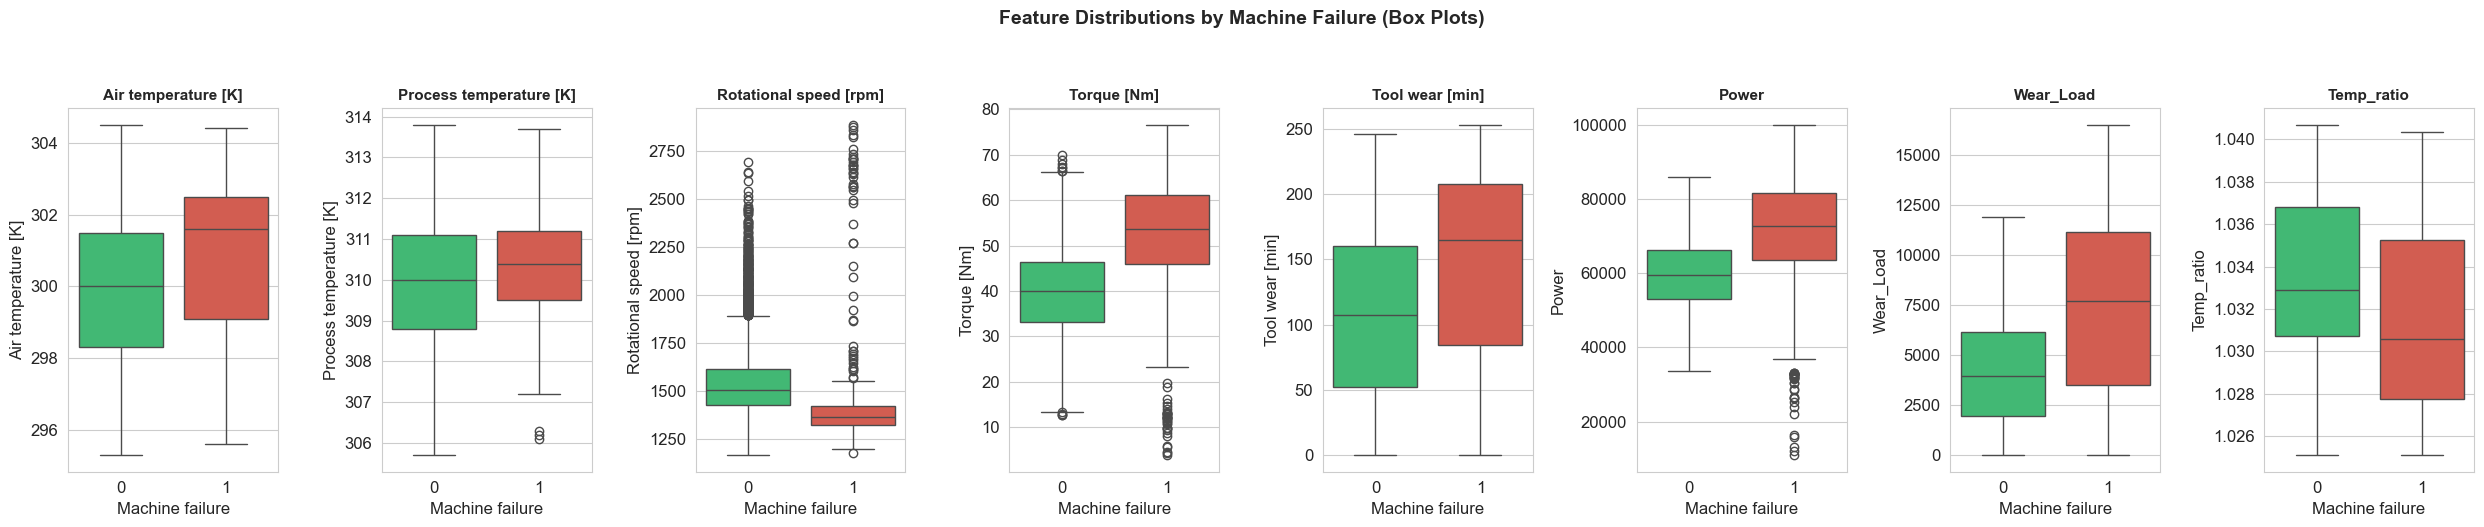

In [13]:
numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power', 'Wear_Load', 'Temp_ratio']

fig, axes = plt.subplots(1, 8, figsize=(25, 5))
for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Machine failure', y=col, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'], hue='Machine failure', legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Feature Distributions by Machine Failure (Box Plots)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

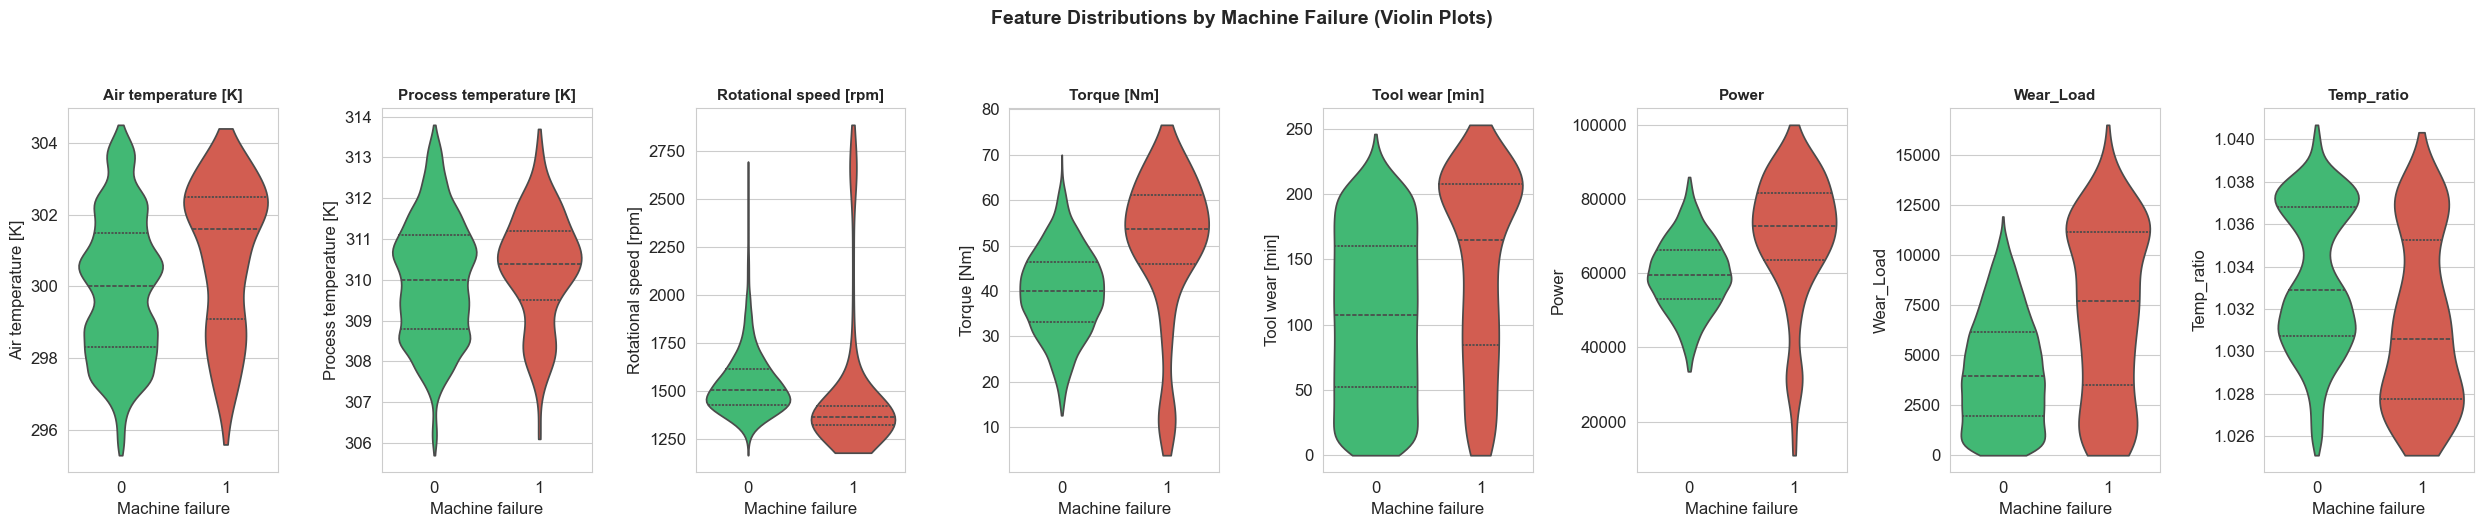

In [14]:
fig, axes = plt.subplots(1, 8, figsize=(25, 5))
for i, col in enumerate(numeric_features):
    sns.violinplot(data=df, x='Machine failure', y=col, ax=axes[i],
                   palette=['#2ecc71', '#e74c3c'], hue='Machine failure', legend=False,
                   inner='quartile', cut=0)
    axes[i].set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Feature Distributions by Machine Failure (Violin Plots)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 2.5 Product Type Analysis

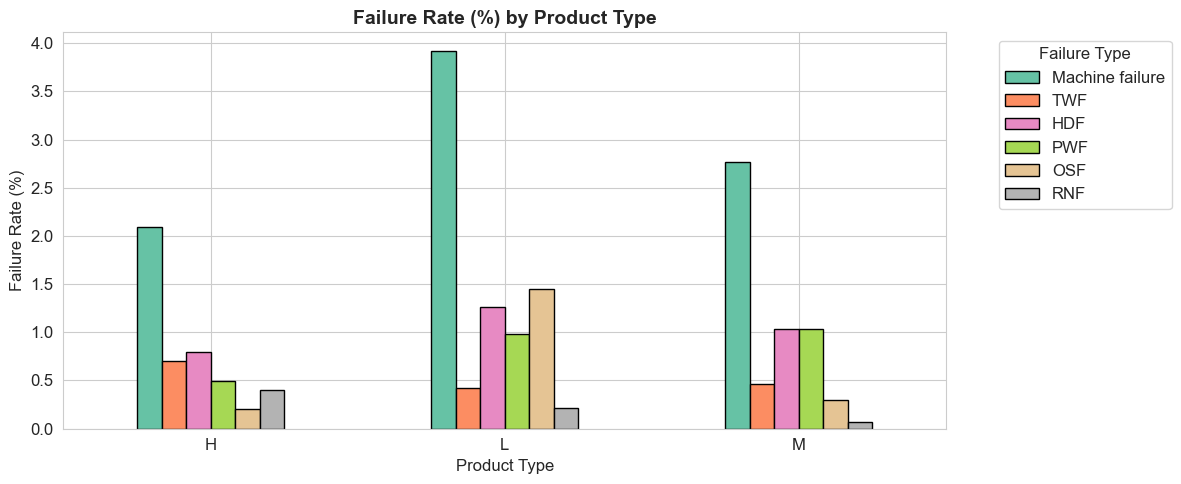

In [15]:
type_failure = df.groupby('Type')[all_tar].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
type_failure.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Failure Rate (%) by Product Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Failure Rate (%)')
ax.set_xlabel('Product Type')
ax.legend(title='Failure Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

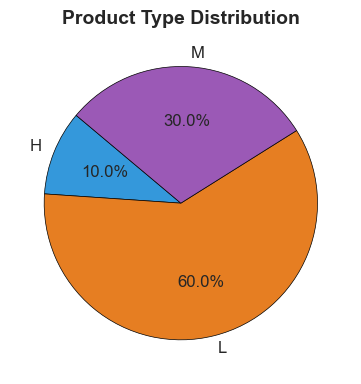

In [16]:
type_counts = df['Type'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
colors = ['#3498db', '#e67e22', '#9b59b6']
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
plt.title('Product Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Outlier Detection

In [17]:
outlier_info = []
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_info)
outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Air temperature [K],298.30,301.50,3.20,293.50,306.30,0,0.00
1,Process temperature [K],308.80,311.10,2.30,305.35,314.55,0,0.00
2,Rotational speed [rpm],1423.00,1612.00,189.00,1139.50,1895.50,418,4.18
3,Torque [Nm],33.20,46.80,13.60,12.80,67.20,69,0.69
4,Tool wear [min],53.00,162.00,109.00,-110.50,325.50,0,0.00
5,Power,53105.40,66873.75,13768.35,32452.88,87526.28,60,0.60
6,Wear_Load,1963.65,6279.00,4315.35,-4509.38,12752.03,20,0.20
7,Temp_ratio,1.03,1.04,0.01,1.02,1.05,0,0.00


### 2.7 Feature Interaction: Torque vs Rotational Speed

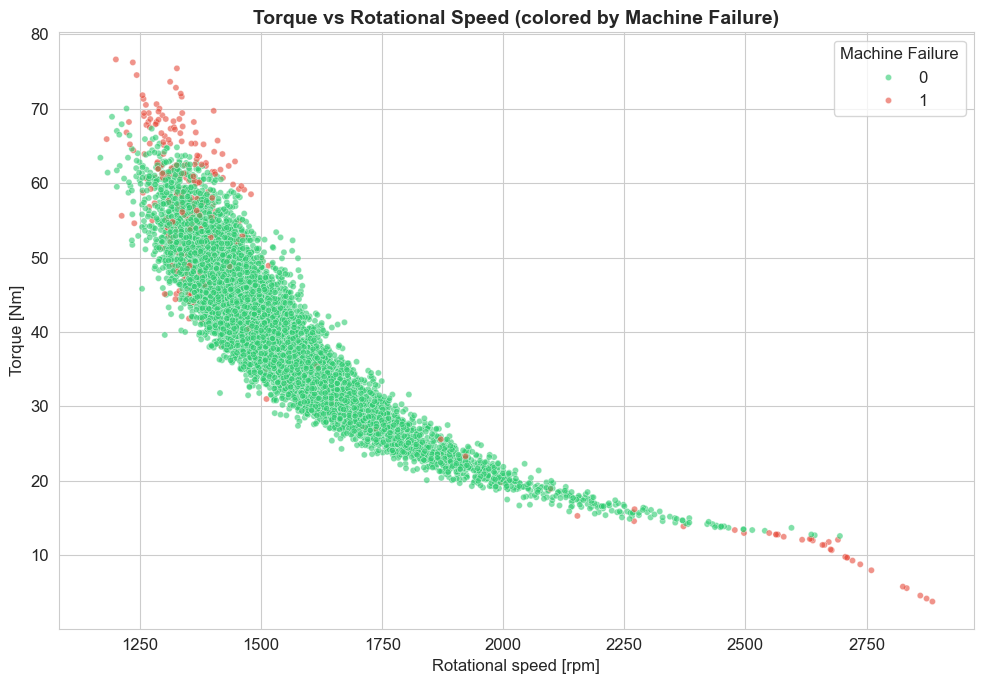

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]',
                hue='Machine failure', palette=['#2ecc71', '#e74c3c'],
                alpha=0.6, s=20)
plt.title('Torque vs Rotational Speed (colored by Machine Failure)', fontsize=14, fontweight='bold')
plt.legend(title='Machine Failure')
plt.tight_layout()
plt.show()

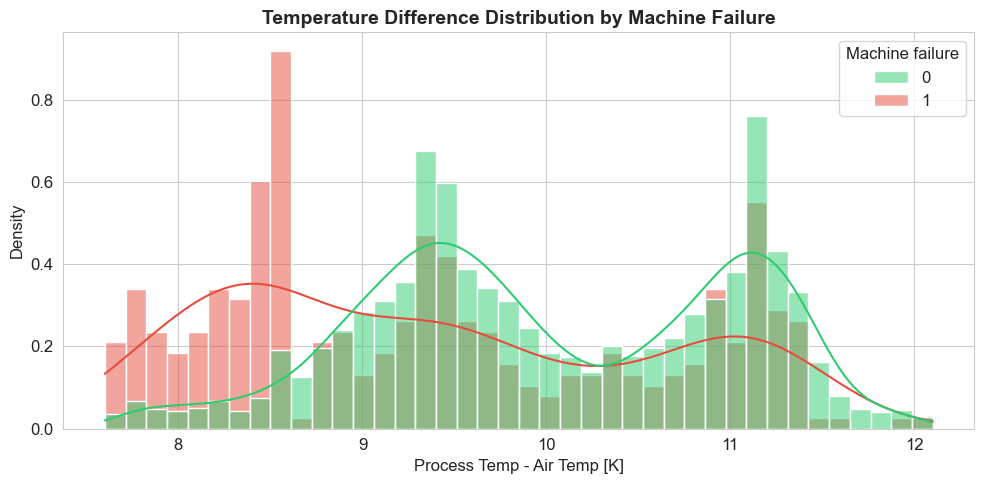

In [19]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Temp_diff', hue='Machine failure', bins=40, kde=True,
             stat='density', common_norm=False, palette=['#2ecc71', '#e74c3c'])
plt.title('Temperature Difference Distribution by Machine Failure', fontsize=14, fontweight='bold')
plt.xlabel('Process Temp - Air Temp [K]')
plt.tight_layout()
plt.show()

df = df.drop(columns=['Temp_diff'])

---
## 3. Model Training

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve, f1_score,
                              precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC
from sklearn.inspection import permutation_importance

train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

print(f'Train size: {len(train)}, Test size: {len(test)}')

Train size: 8000, Test size: 2000


In [21]:
def prepare_data(df_in, tar, use_smote=True, scale=False):
    """Prepare train data with encoding, optional SMOTE, optional scaling."""
    X = df_in.drop(columns=all_tar).copy()
    y = df_in[tar]
    X['Type'] = X['Type'].map({'L': 0, 'M': 1, 'H': 2})
    
    scaler = None
    if use_smote:
        cat_index = [X.columns.get_loc('Type')]
        smote = SMOTENC(categorical_features=cat_index, random_state=42)
        X, y = smote.fit_resample(X, y)
    
    if scale:
        scaler = StandardScaler()
        X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns) if isinstance(X, pd.DataFrame) else scaler.fit_transform(X)
    
    return X, y, scaler

def prepare_test(df_in, tar, scaler=None):
    """Prepare test data with encoding and optional scaling."""
    X = df_in.drop(columns=all_tar).copy()
    y = df_in[tar]
    X['Type'] = X['Type'].map({'L': 0, 'M': 1, 'H': 2})
    if scaler is not None:
        X = pd.DataFrame(scaler.transform(X), columns=X.columns) if isinstance(X, pd.DataFrame) else scaler.transform(X)
    return X, y

In [22]:
def train_all_models(train_df, target):
    """Train all models for a given target and return dict of {name: (model, scaler, feature_names)}."""
    models = {}
    
    # Random Forest
    X, y, _ = prepare_data(train_df, target, use_smote=True, scale=False)
    rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
    rf.fit(X, y)
    feature_names = X.columns.tolist() if isinstance(X, pd.DataFrame) else [f'f{i}' for i in range(X.shape[1])]
    models['Random Forest'] = (rf, None, feature_names)
    
    # Logistic Regression
    X, y, _ = prepare_data(train_df, target, use_smote=True, scale=False)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X, y)
    models['Logistic Regression'] = (lr, None, feature_names)
    
    # Decision Tree
    X, y, _ = prepare_data(train_df, target, use_smote=True, scale=False)
    dt = DecisionTreeClassifier(max_depth=None, random_state=42)
    dt.fit(X, y)
    models['Decision Tree'] = (dt, None, feature_names)
    
    # Neural Network
    X, y, scaler = prepare_data(train_df, target, use_smote=True, scale=True)
    nn = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42)
    nn.fit(X, y)
    models['Neural Network'] = (nn, scaler, feature_names)
    
    # LDA
    X, y, scaler = prepare_data(train_df, target, use_smote=True, scale=True)
    lda = LinearDiscriminantAnalysis()
    lda.fit(X, y)
    models['LDA'] = (lda, scaler, feature_names)
    
    # QDA
    X, y, scaler = prepare_data(train_df, target, use_smote=True, scale=True)
    qda = QuadraticDiscriminantAnalysis()
    qda.fit(X, y)
    models['QDA'] = (qda, scaler, feature_names)
    
    # SVM
    X, y, scaler = prepare_data(train_df, target, use_smote=True, scale=True)
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    svm.fit(X, y)
    models['SVM'] = (svm, scaler, feature_names)
    
    # Naive Bayes
    X, y, scaler = prepare_data(train_df, target, use_smote=True, scale=True)
    gnb = GaussianNB()
    gnb.fit(X, y)
    models['Naive Bayes'] = (gnb, scaler, feature_names)
    
    return models

In [23]:
# Train all models for the primary target: Machine failure
primary_target = 'Machine failure'
print(f'Training models for target: {primary_target}...')
trained_models = train_all_models(train, primary_target)
print(f'Trained {len(trained_models)} models.')

Training models for target: Machine failure...
Trained 8 models.


---
## 4. Feature Importance Analysis

### 4.1 Random Forest Feature Importance (Gini Importance)

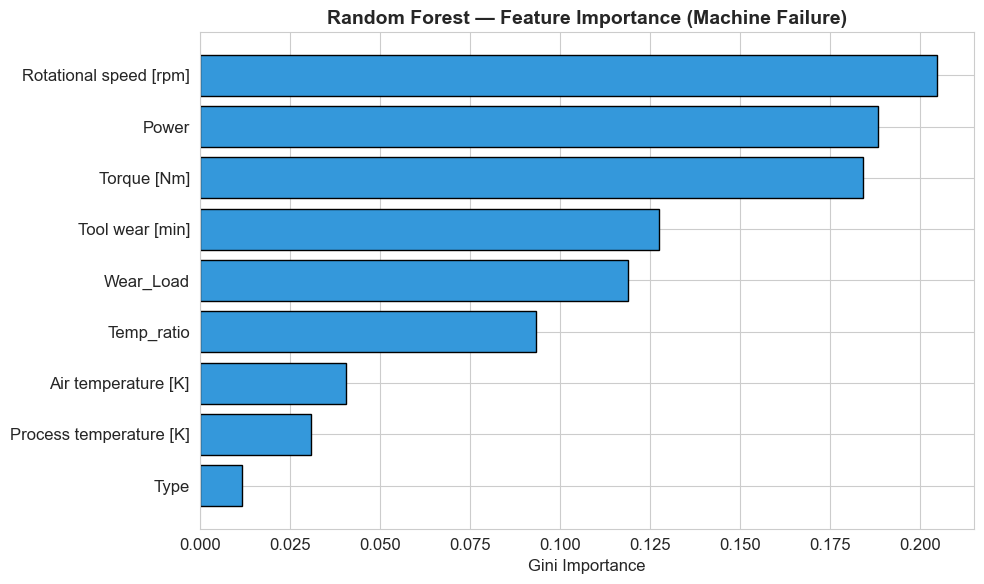

In [24]:
rf_model, _, feat_names = trained_models['Random Forest']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='#3498db', edgecolor='black')
plt.xlabel('Gini Importance')
plt.title('Random Forest — Feature Importance (Machine Failure)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Logistic Regression Coefficients

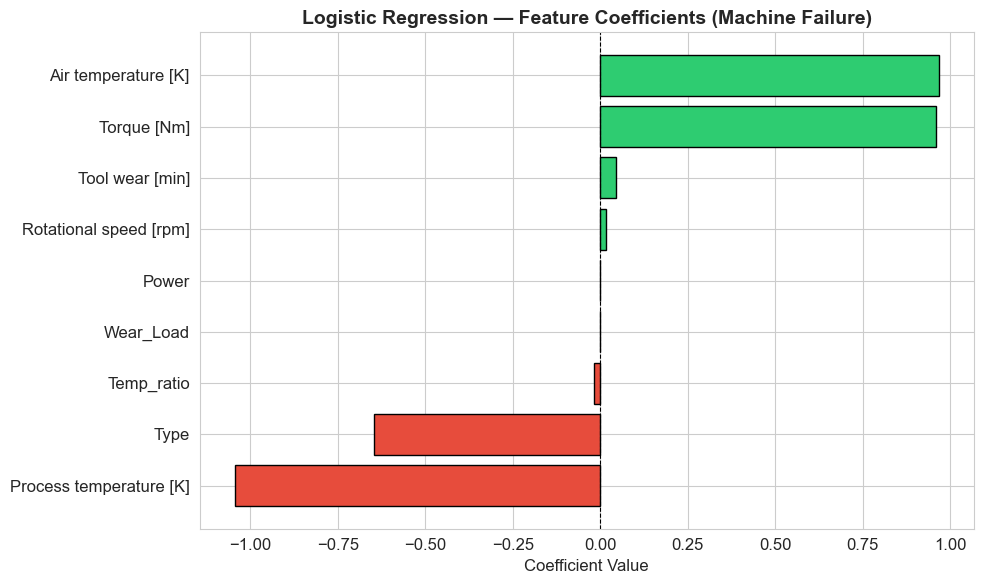

In [25]:
lr_model, _, feat_names = trained_models['Logistic Regression']
coefs = lr_model.coef_[0]
coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coefs}).sort_values('Coefficient')

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression — Feature Coefficients (Machine Failure)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### 4.3 Decision Tree Feature Importance

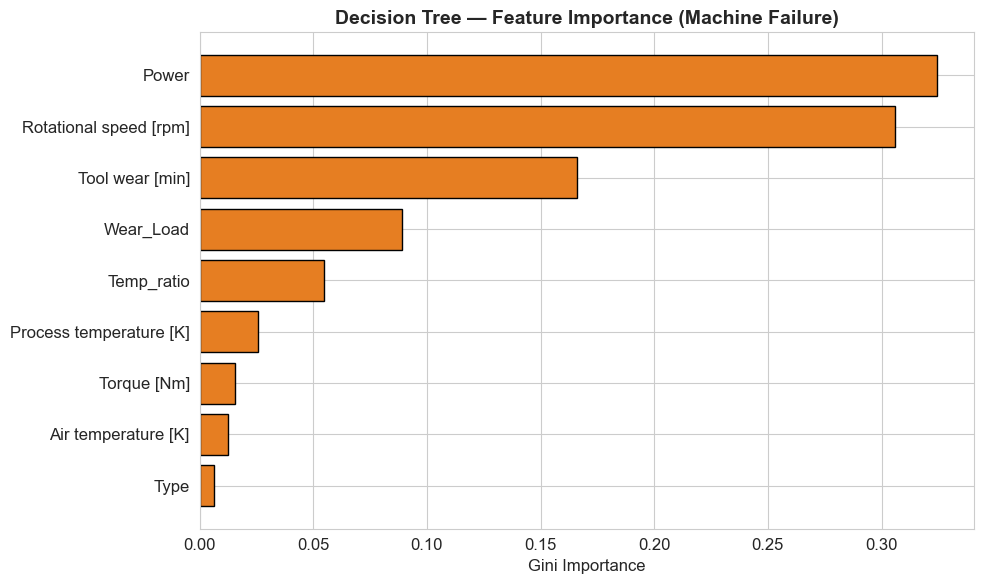

In [26]:
dt_model, _, feat_names = trained_models['Decision Tree']
importances_dt = dt_model.feature_importances_
feat_imp_dt_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances_dt}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_dt_df['Feature'], feat_imp_dt_df['Importance'], color='#e67e22', edgecolor='black')
plt.xlabel('Gini Importance')
plt.title('Decision Tree — Feature Importance (Machine Failure)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Permutation Importance (Model-Agnostic)

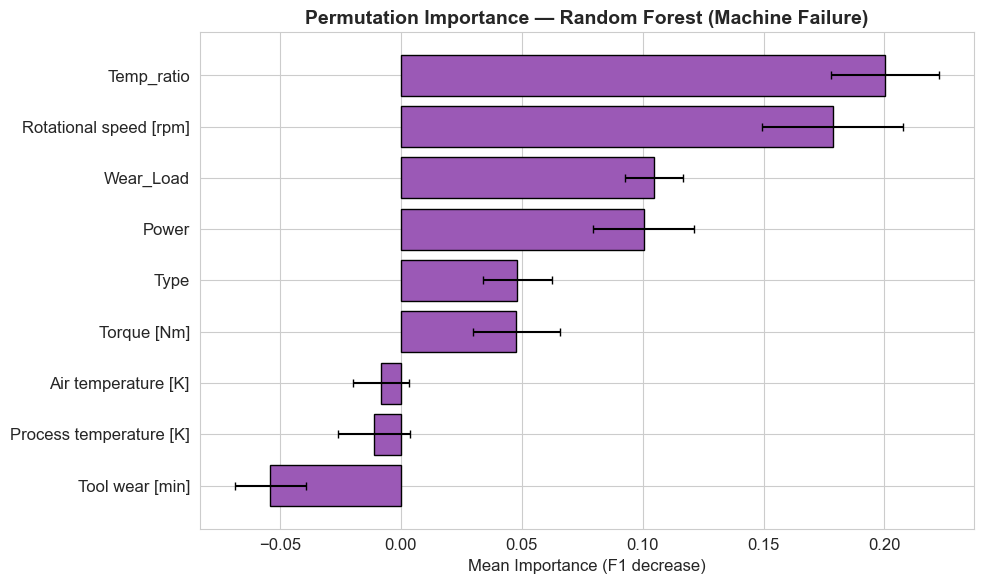

In [27]:
# Permutation importance on test set for Random Forest
X_test_pi, y_test_pi = prepare_test(test, primary_target, scaler=None)

perm_imp = permutation_importance(rf_model, X_test_pi, y_test_pi,
                                   n_repeats=20, random_state=42, scoring='f1')

perm_imp_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance Mean': perm_imp.importances_mean,
    'Importance Std': perm_imp.importances_std
}).sort_values('Importance Mean', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(perm_imp_df['Feature'], perm_imp_df['Importance Mean'],
         xerr=perm_imp_df['Importance Std'], color='#9b59b6', edgecolor='black', capsize=3)
plt.xlabel('Mean Importance (F1 decrease)')
plt.title('Permutation Importance — Random Forest (Machine Failure)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Feature Importance Comparison Across All Targets

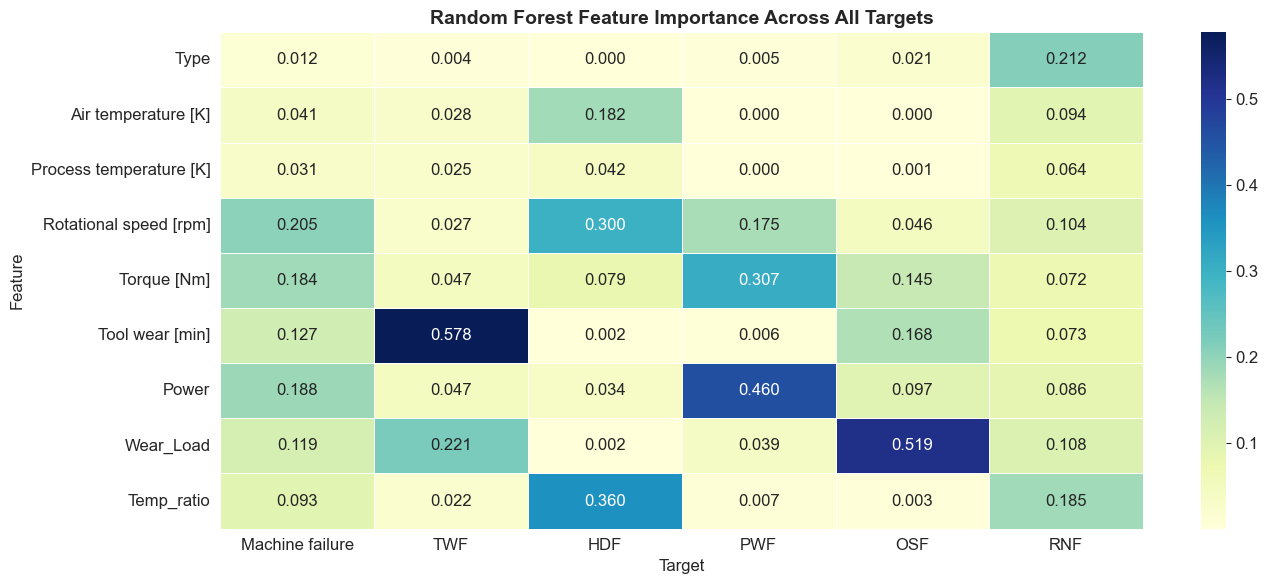

In [28]:
# Train Random Forest for each target and collect feature importances
rf_importances = {}
for tar in all_tar:
    X_tr, y_tr, _ = prepare_data(train, tar, use_smote=True, scale=False)
    rf_temp = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
    rf_temp.fit(X_tr, y_tr)
    fnames = X_tr.columns.tolist() if isinstance(X_tr, pd.DataFrame) else [f'f{i}' for i in range(X_tr.shape[1])]
    rf_importances[tar] = dict(zip(fnames, rf_temp.feature_importances_))

imp_matrix = pd.DataFrame(rf_importances)

plt.figure(figsize=(14, 6))
sns.heatmap(imp_matrix, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Random Forest Feature Importance Across All Targets', fontsize=14, fontweight='bold')
plt.ylabel('Feature')
plt.xlabel('Target')
plt.tight_layout()
plt.show()

---
## 5. Confusion Matrices

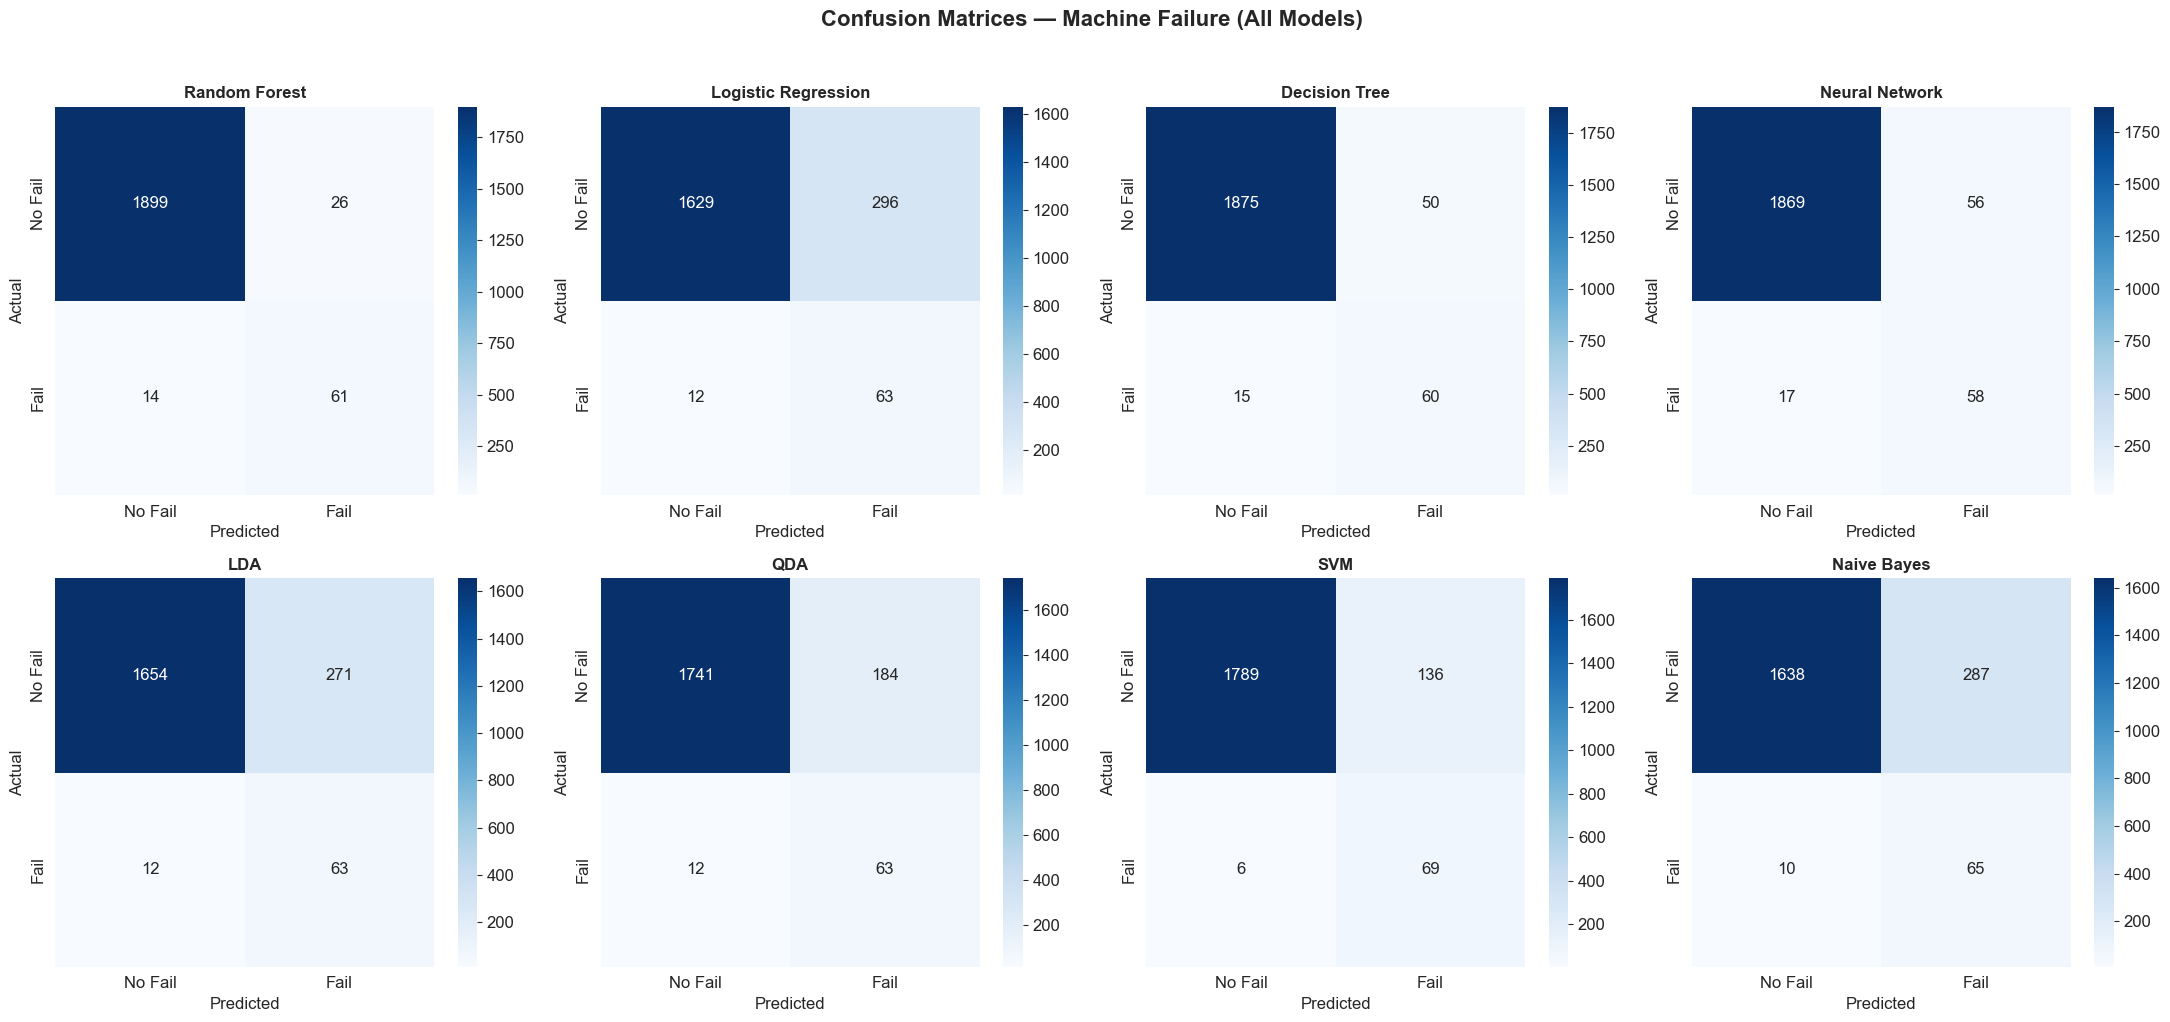

In [29]:
# Confusion matrices for all models on Machine Failure
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

model_names = list(trained_models.keys())

for i, name in enumerate(model_names):
    model, scaler, _ = trained_models[name]
    X_t, y_t = prepare_test(test, primary_target, scaler=scaler)
    y_pred = model.predict(X_t)
    cm = confusion_matrix(y_t, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Fail', 'Fail'], yticklabels=['No Fail', 'Fail'])
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Hide last empty subplot if models < 8
for j in range(len(model_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — Machine Failure (All Models)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. ROC Curves

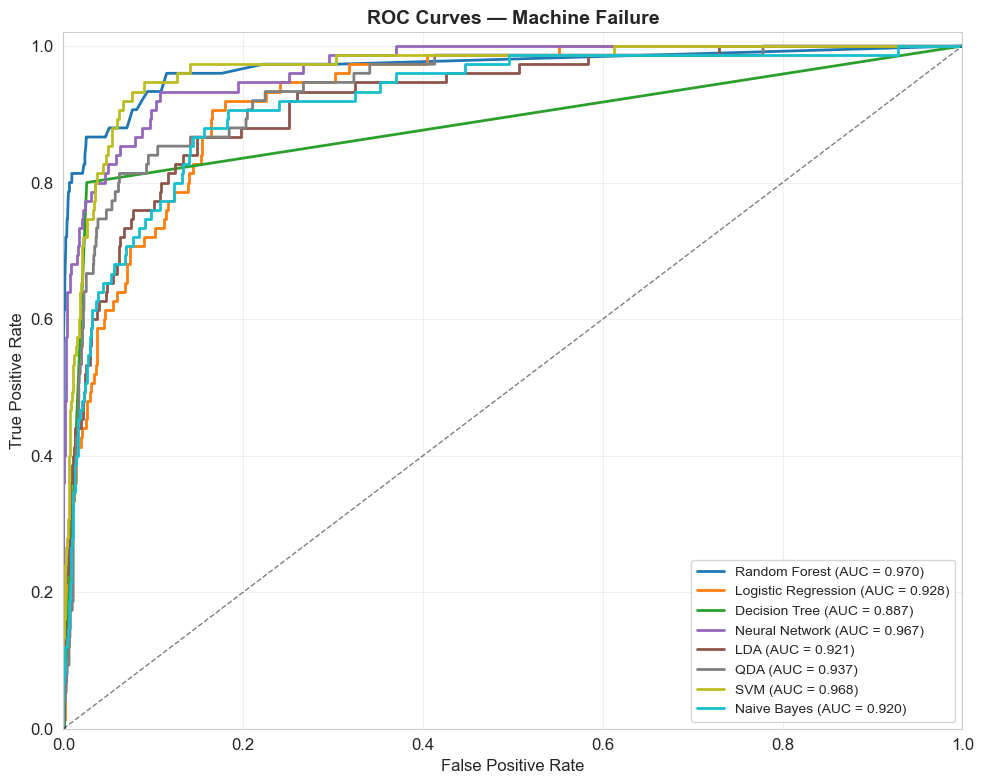

In [30]:
# ROC curves for models that support predict_proba (Machine Failure)
plt.figure(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

for (name, (model, scaler, _)), color in zip(trained_models.items(), colors):
    X_t, y_t = prepare_test(test, primary_target, scaler=scaler)
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_t)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_proba = model.decision_function(X_t)
        else:
            continue
        fpr, tpr, _ = roc_curve(y_t, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
    except Exception as e:
        print(f'Skipping {name}: {e}')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Machine Failure', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Precision-Recall Curves

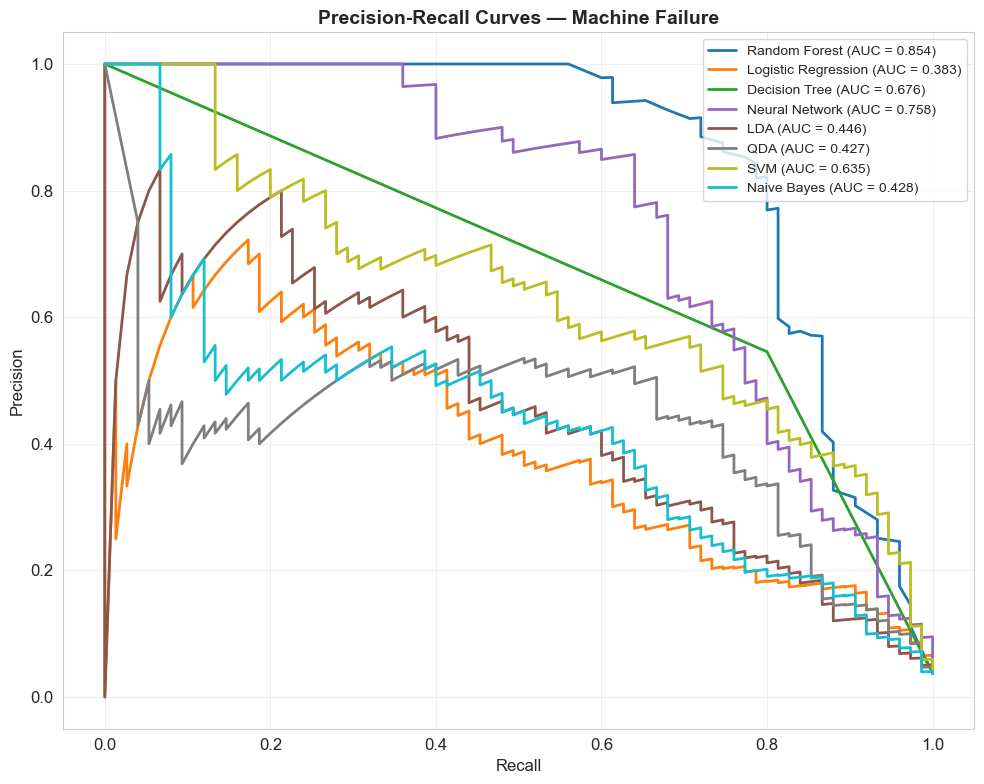

In [31]:
# Precision-Recall curves (important for imbalanced datasets)
plt.figure(figsize=(10, 8))

for (name, (model, scaler, _)), color in zip(trained_models.items(), colors):
    X_t, y_t = prepare_test(test, primary_target, scaler=scaler)
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_t)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_proba = model.decision_function(X_t)
        else:
            continue
        precision, recall, _ = precision_recall_curve(y_t, y_proba)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, color=color, lw=2, label=f'{name} (AUC = {pr_auc:.3f})')
    except Exception as e:
        print(f'Skipping {name}: {e}')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — Machine Failure', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Comprehensive Model Comparison

In [33]:
# Evaluate all models across all targets
results = []

for tar in all_tar:
    models_for_tar = train_all_models(train, tar)
    for name, (model, scaler, _) in models_for_tar.items():
        X_t, y_t = prepare_test(test, tar, scaler=scaler)
        y_pred = model.predict(X_t)
        
        acc = accuracy_score(y_t, y_pred)
        f1 = f1_score(y_t, y_pred, zero_division=0)
        prec = precision_score(y_t, y_pred, zero_division=0)
        rec = recall_score(y_t, y_pred, zero_division=0)
        
        results.append({
            'Target': tar,
            'Model': name,
            'Accuracy': round(acc, 4),
            'F1 Score': round(f1, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4)
        })

results_df = pd.DataFrame(results)
print('All models evaluated.')
results_df.head(20)

All models evaluated.


,Target,Model,Accuracy,F1 Score,Precision,Recall
0,Machine failure,Random Forest,0.9800,0.7531,0.7011,0.8133
1,Machine failure,Logistic Regression,0.8460,0.2903,0.1755,0.8400
2,Machine failure,Decision Tree,0.9675,0.6486,0.5455,0.8000
3,Machine failure,Neural Network,0.9635,0.6138,0.5088,0.7733
4,Machine failure,LDA,0.8585,0.3081,0.1886,0.8400
5,Machine failure,QDA,0.9020,0.3913,0.2551,0.8400
6,Machine failure,SVM,0.9290,0.4929,0.3366,0.9200
7,Machine failure,Naive Bayes,0.8515,0.3044,0.1847,0.8667
8,TWF,Random Forest,0.9820,0.0526,0.0385,0.0833
9,TWF,Logistic Regression,0.9170,0.1263,0.0674,1.0000


### 8.1 F1 Score Heatmap Across All Models and Targets

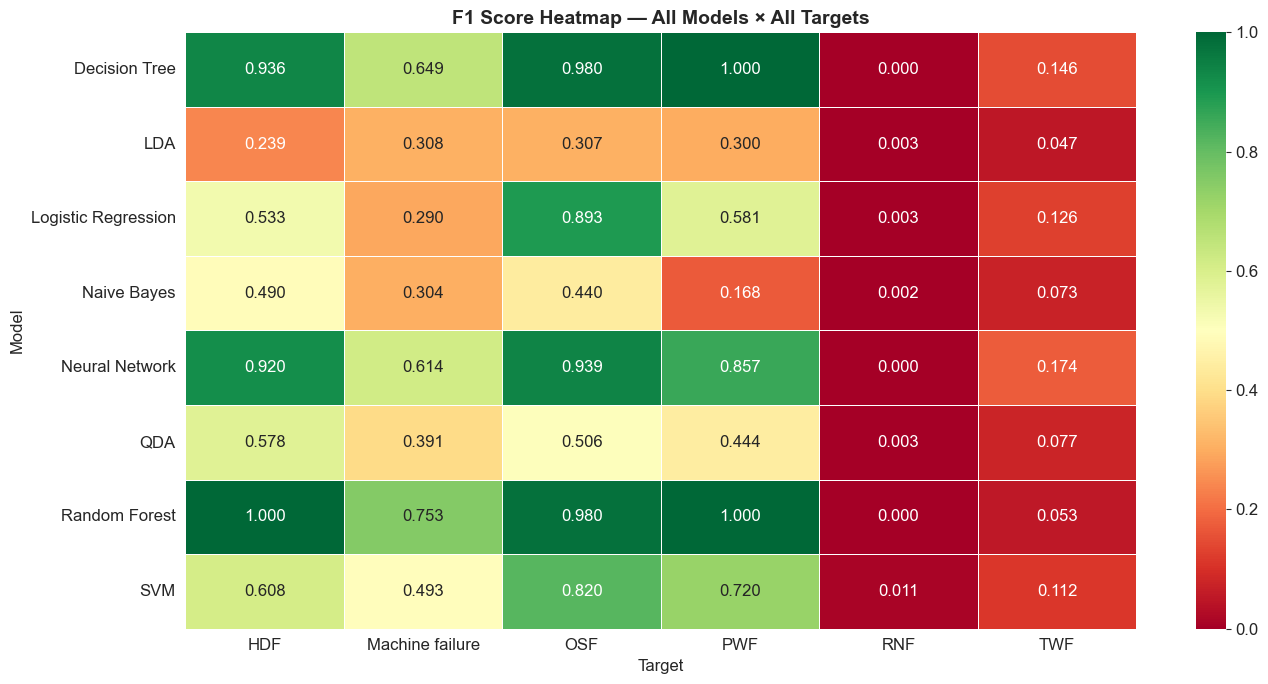

In [34]:
f1_pivot = results_df.pivot_table(index='Model', columns='Target', values='F1 Score')

plt.figure(figsize=(14, 7))
sns.heatmap(f1_pivot, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5,
            vmin=0, vmax=1)
plt.title('F1 Score Heatmap — All Models × All Targets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Accuracy Heatmap

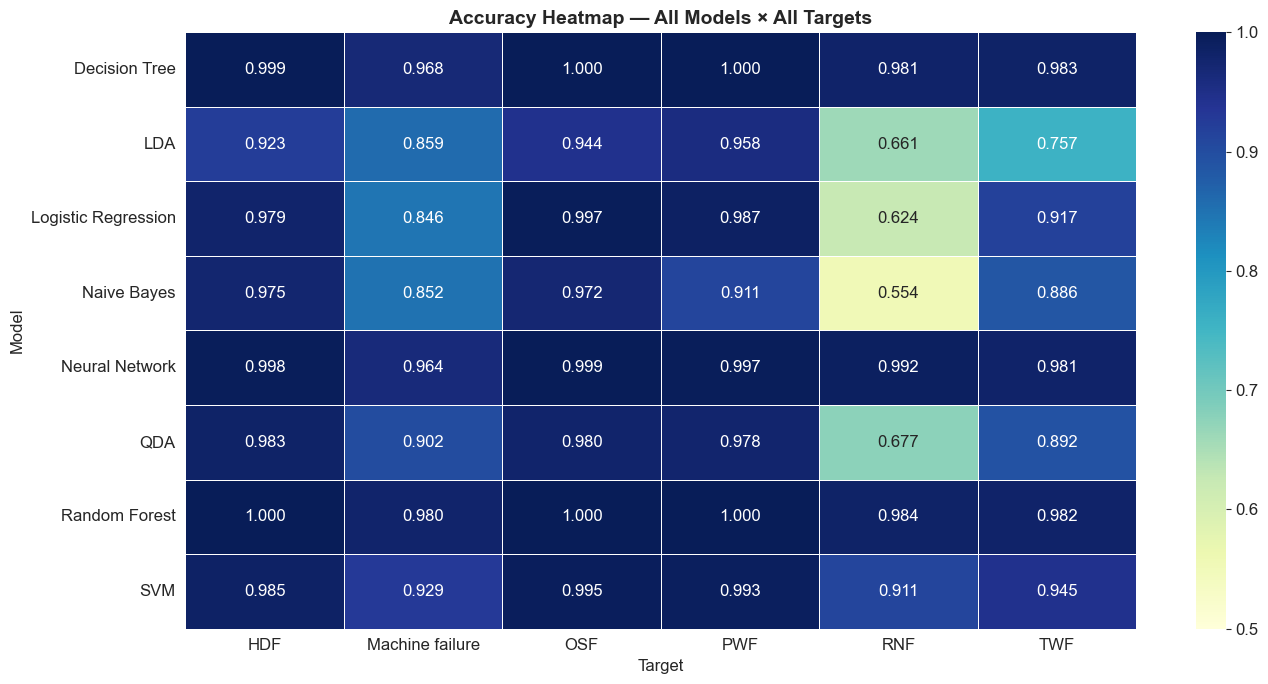

In [35]:
acc_pivot = results_df.pivot_table(index='Model', columns='Target', values='Accuracy')

plt.figure(figsize=(14, 7))
sns.heatmap(acc_pivot, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5,
            vmin=0.5, vmax=1)
plt.title('Accuracy Heatmap — All Models × All Targets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Best Model Per Target

In [36]:
# Best model by F1 score for each target
best_models = results_df.loc[results_df.groupby('Target')['F1 Score'].idxmax()]
best_models = best_models[['Target', 'Model', 'F1 Score', 'Accuracy', 'Precision', 'Recall']]
best_models = best_models.sort_values('F1 Score', ascending=False)
print('\nBest Model per Target (by F1 Score):')
best_models


Best Model per Target (by F1 Score):


,Target,Model,F1 Score,Accuracy,Precision,Recall
16,HDF,Random Forest,1.0000,1.0000,1.0000,1.0000
24,PWF,Random Forest,1.0000,1.0000,1.0000,1.0000
32,OSF,Random Forest,0.9796,0.9995,1.0000,0.9600
0,Machine failure,Random Forest,0.7531,0.9800,0.7011,0.8133
11,TWF,Neural Network,0.1739,0.9810,0.1176,0.3333
46,RNF,SVM,0.0111,0.9110,0.0056,0.3333


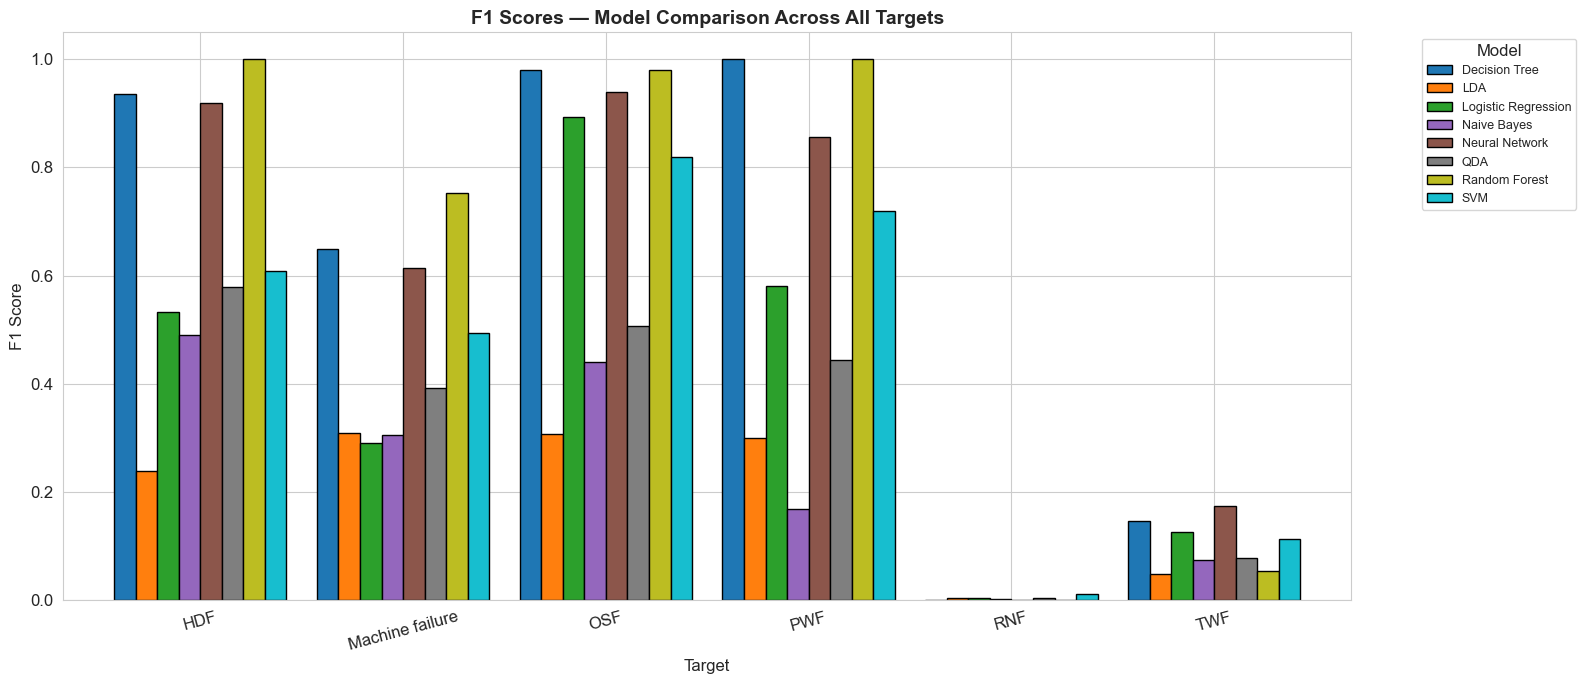

In [37]:
# Grouped bar chart of F1 scores
fig, ax = plt.subplots(figsize=(16, 7))
f1_pivot.T.plot(kind='bar', ax=ax, width=0.85, edgecolor='black', colormap='tab10')
ax.set_title('F1 Scores — Model Comparison Across All Targets', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Target')
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 8.4 Recall vs Precision Scatter (Machine Failure)

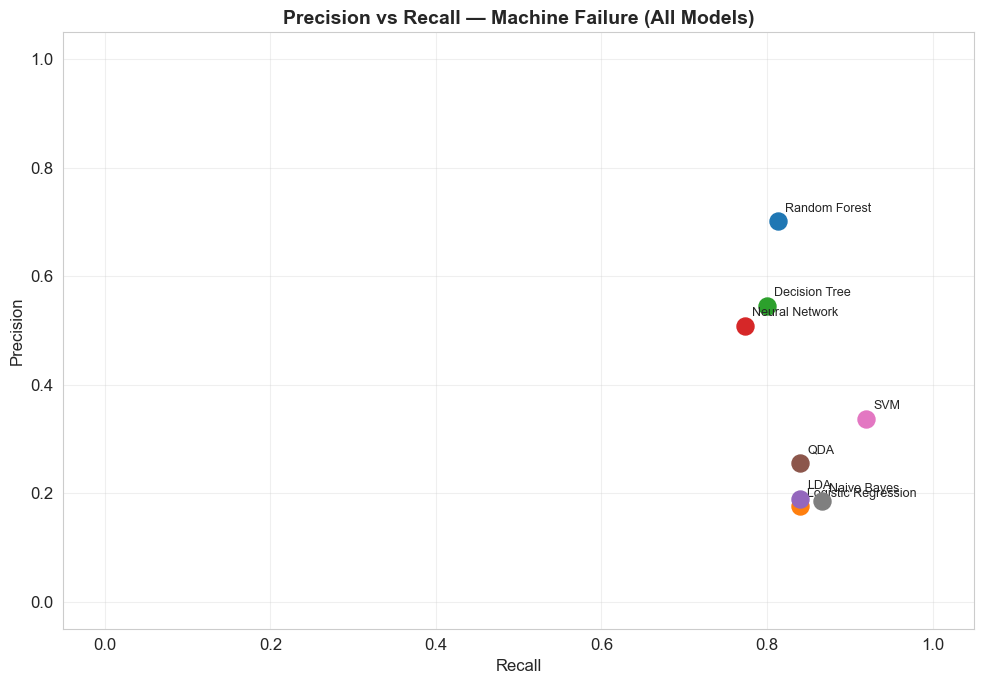

In [38]:
mf_results = results_df[results_df['Target'] == 'Machine failure']

plt.figure(figsize=(10, 7))
for i, row in mf_results.iterrows():
    plt.scatter(row['Recall'], row['Precision'], s=150, zorder=3)
    plt.annotate(row['Model'], (row['Recall'], row['Precision']),
                 fontsize=9, ha='left', va='bottom',
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision vs Recall — Machine Failure (All Models)', fontsize=14, fontweight='bold')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. SHAP-based Interpretability (Random Forest)

In [39]:
try:
    import shap
    shap_available = True
except ImportError:
    print('SHAP not installed. Install with: pip install shap')
    print('Skipping SHAP analysis.')
    shap_available = False

<Figure size 1000x600 with 0 Axes>

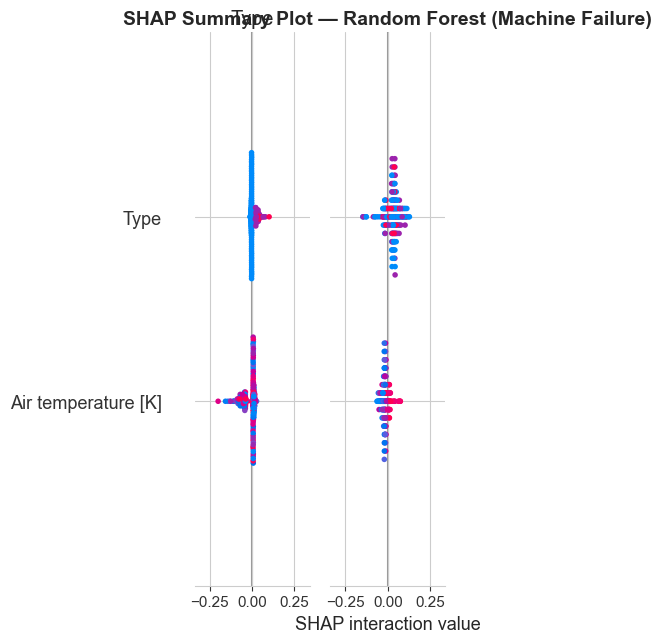

In [40]:
if shap_available:
    rf_model, _, feat_names = trained_models['Random Forest']
    X_test_shap, y_test_shap = prepare_test(test, primary_target, scaler=None)
    
    # Use a subsample for speed
    X_sample = X_test_shap.sample(min(200, len(X_test_shap)), random_state=42)
    
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)
    
    # For binary classification, shap_values is a list of 2; use class 1 (failure)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values, 
                      X_sample, feature_names=feat_names, show=False)
    plt.title('SHAP Summary Plot — Random Forest (Machine Failure)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

<Figure size 1000x600 with 0 Axes>

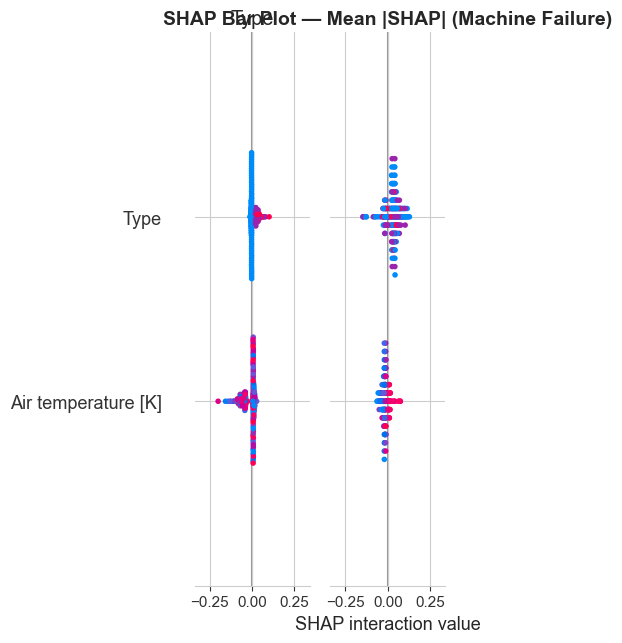

In [41]:
if shap_available:
    # SHAP bar plot (mean absolute SHAP values)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                      X_sample, feature_names=feat_names, plot_type='bar', show=False)
    plt.title('SHAP Bar Plot — Mean |SHAP| (Machine Failure)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 10. Decision Tree Visualization

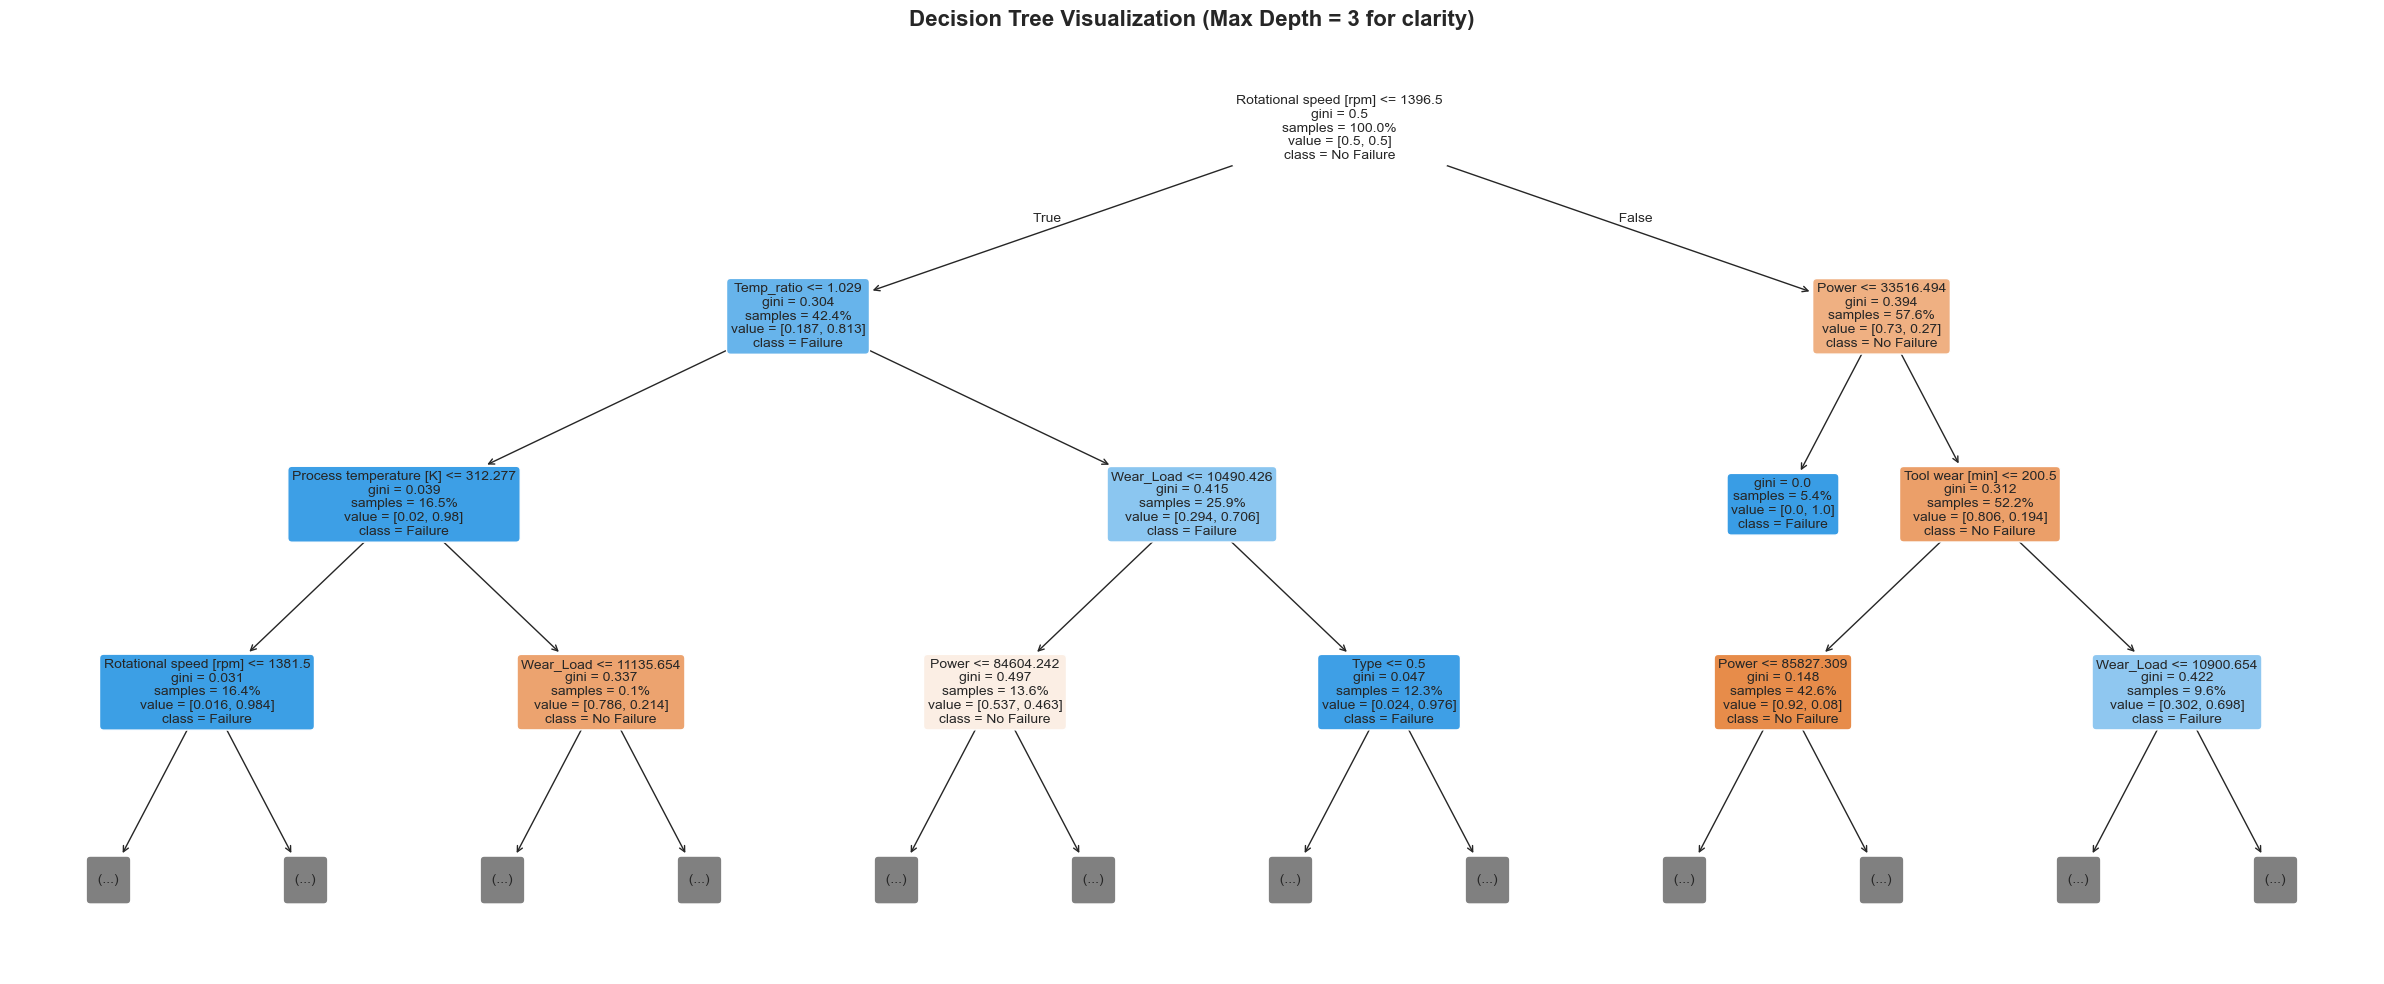

In [42]:
from sklearn.tree import plot_tree

dt_model, _, feat_names = trained_models['Decision Tree']

# Plot a shallow version of the tree (max_depth=3 for readability)
plt.figure(figsize=(24, 10))
plot_tree(dt_model, max_depth=3, feature_names=feat_names,
          class_names=['No Failure', 'Failure'], filled=True,
          rounded=True, fontsize=10, proportion=True)
plt.title('Decision Tree Visualization (Max Depth = 3 for clarity)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Summary & Conclusions

In [43]:
# Print summary table
print('='*80)
print('SUMMARY: Best Model per Target (by F1 Score)')
print('='*80)
for _, row in best_models.iterrows():
    print(f"  {row['Target']:20s} -> {row['Model']:25s} | F1={row['F1 Score']:.4f} | Acc={row['Accuracy']:.4f} | P={row['Precision']:.4f} | R={row['Recall']:.4f}")

print('\n' + '='*80)
print('KEY FINDINGS:')
print('='*80)
print('1. The dataset is highly imbalanced — most failure types have < 5% positive rate.')
print('2. SMOTENC oversampling was applied to handle the imbalance.')
print('3. Tree-based models (Random Forest, Decision Tree) tend to perform well due to')
print('   their ability to capture non-linear relationships.')
print('4. Torque and Rotational Speed are consistently the most important features.')
print('5. Product Type (L/M/H) affects failure rates — "H" type has lower failure rates.')
print('6. Some failure types (TWF, RNF) are extremely rare, making prediction very challenging.')

SUMMARY: Best Model per Target (by F1 Score)
  HDF                  -> Random Forest             | F1=1.0000 | Acc=1.0000 | P=1.0000 | R=1.0000
  PWF                  -> Random Forest             | F1=1.0000 | Acc=1.0000 | P=1.0000 | R=1.0000
  OSF                  -> Random Forest             | F1=0.9796 | Acc=0.9995 | P=1.0000 | R=0.9600
  Machine failure      -> Random Forest             | F1=0.7531 | Acc=0.9800 | P=0.7011 | R=0.8133
  TWF                  -> Neural Network            | F1=0.1739 | Acc=0.9810 | P=0.1176 | R=0.3333
  RNF                  -> SVM                       | F1=0.0111 | Acc=0.9110 | P=0.0056 | R=0.3333

KEY FINDINGS:
1. The dataset is highly imbalanced — most failure types have < 5% positive rate.
2. SMOTENC oversampling was applied to handle the imbalance.
3. Tree-based models (Random Forest, Decision Tree) tend to perform well due to
   their ability to capture non-linear relationships.
4. Torque and Rotational Speed are consistently the most important fe